In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv(r"E:\engg\Data\sales_data.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [4]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

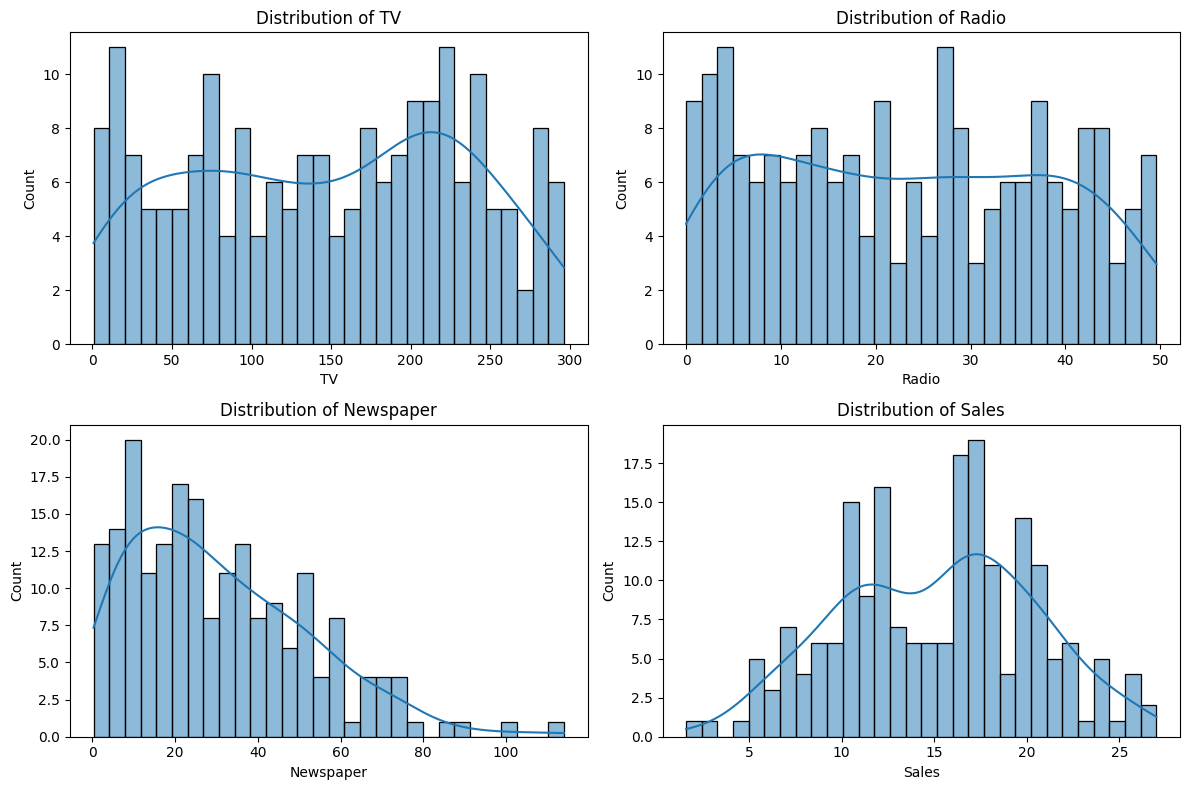

In [8]:
cols = ['TV', 'Radio', 'Newspaper', 'Sales']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax, bins=30)
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

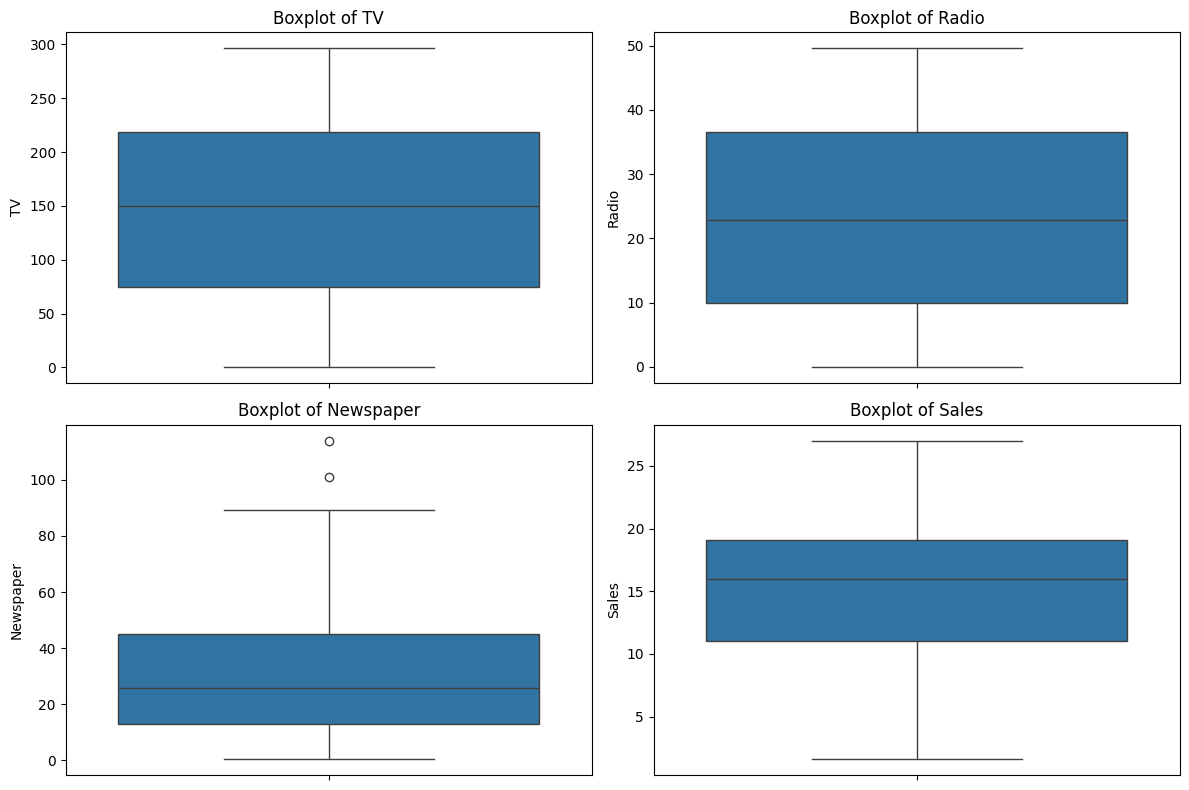

In [9]:
cols = ['TV', 'Radio', 'Newspaper', 'Sales']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

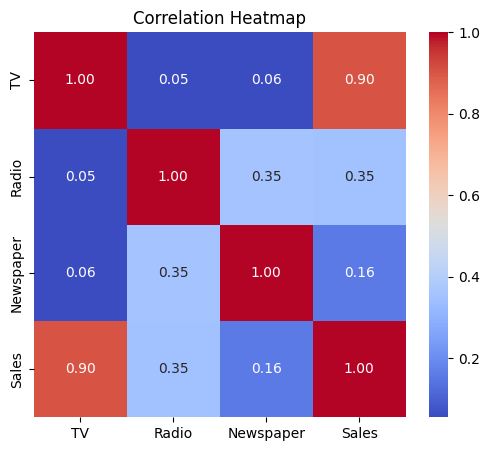

In [10]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [12]:
x = df.drop('Sales',axis=1)
y = df["Sales"]

In [13]:
x_train,x_test,y_train,y_test= train_test_split(x,y, test_size=0.2, random_state=42)

In [14]:
model = LinearRegression()

In [15]:
model= model.fit(x_train,y_train)

In [16]:
y_pred = model.predict(x_test)

In [17]:
mae= mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2_score=r2_score(y_test,y_pred)

print(f"MAE = {mae}")
print(f"MSE = {mse}")
print(f"r2 score = {r2_score}")

MAE = 1.2748262109549338
MSE = 2.9077569102710896
r2 score = 0.9059011844150826


In [18]:
import pickle
with open('sales.pkl', 'wb') as fh:
    pickle.dump(model, fh)

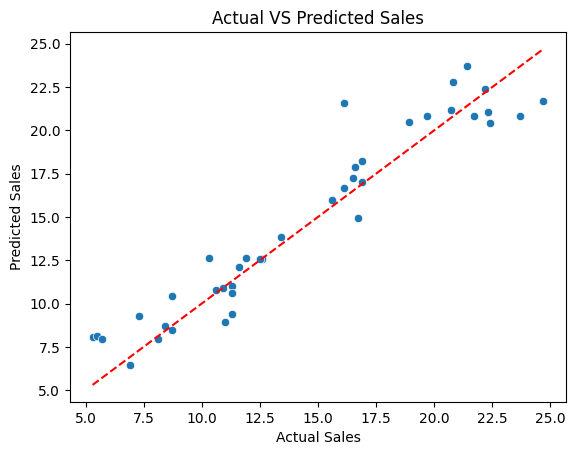

In [20]:
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red',linestyle='--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual VS Predicted Sales")
plt.show()

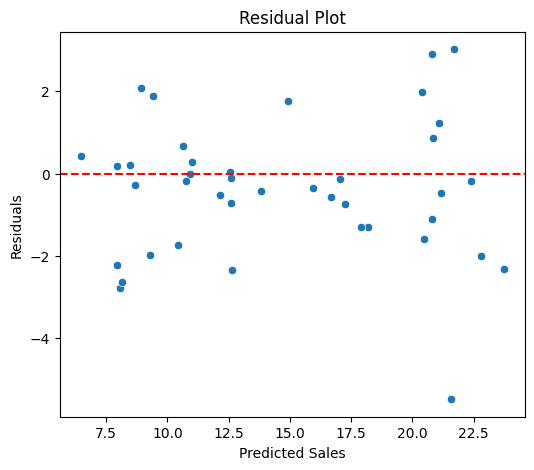

In [21]:
residuals = y_test - y_pred
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()